# House Price Prediction with Regression

## Project Overview

This is my seventh Python data science project.

In this project, I build regression models to predict house prices using the House Prices dataset from Kaggle.

The goal is to practice:

- Loading a real regression dataset
- Understanding the difference between classification and regression
- Exploring the target variable
- Handling missing values
- Processing numeric and categorical features
- Building machine learning pipelines
- Training regression models
- Evaluating models using RMSE
- Creating a Kaggle submission file

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

In [183]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [184]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")

train.head()

test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [185]:
train.shape

test.shape

train.info()

train.describe()

train.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

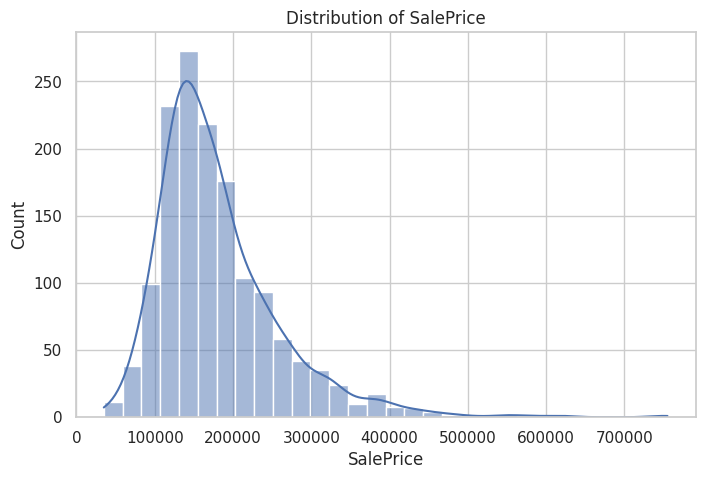

In [186]:
train["SalePrice"].head()

train["SalePrice"].describe()

plt.figure(figsize=(8, 5))

sns.histplot(train["SalePrice"], bins=30, kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

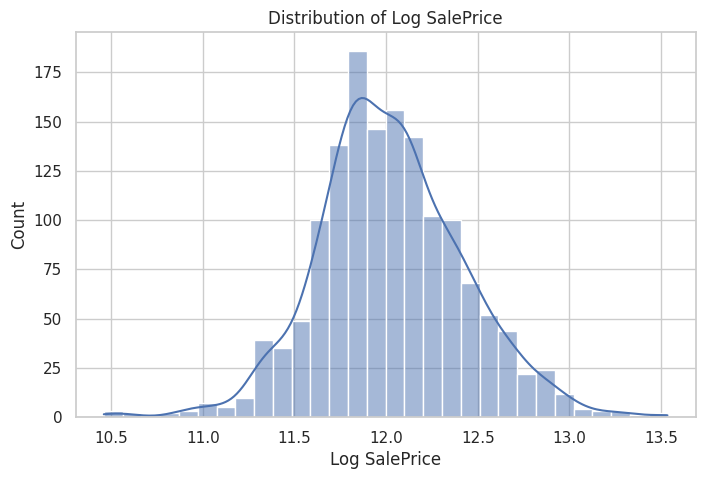

In [187]:
train["SalePrice_Log"] = np.log1p(train["SalePrice"])

plt.figure(figsize=(8, 5))

sns.histplot(train["SalePrice_Log"], bins=30, kde=True)

plt.title("Distribution of Log SalePrice")
plt.xlabel("Log SalePrice")
plt.ylabel("Count")
plt.show()

In [188]:
missing_values = train.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0].head(20)

missing_percent = (train.isnull().sum() / len(train) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": train.isnull().sum(),
    "Missing Percentage": missing_percent
}).sort_values("Missing Values", ascending=False)

missing_summary[missing_summary["Missing Values"] > 0].head(20)

,Missing Values,Missing Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


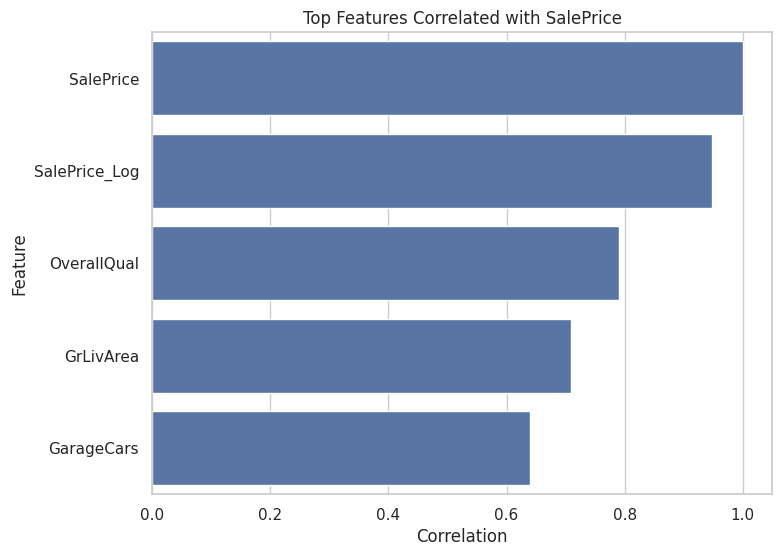

In [189]:
numeric_train = train.select_dtypes(include=["int64", "float64"])

correlations = numeric_train.corr()["SalePrice"].sort_values(ascending=False)

correlations.head(5)

top_corr = correlations.head(5)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

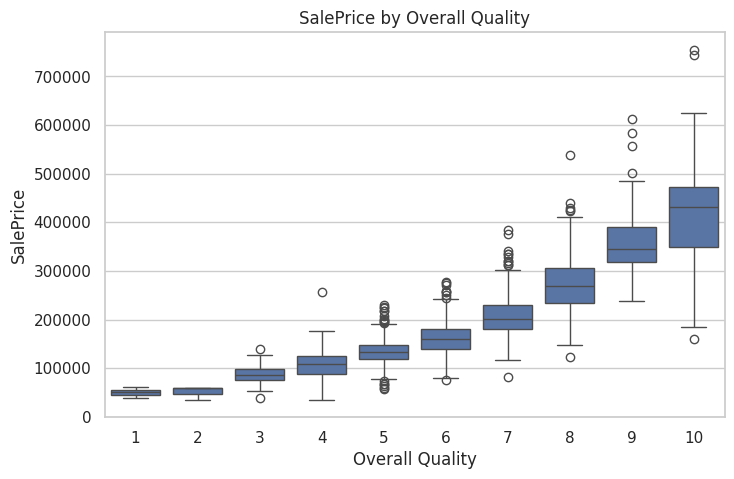

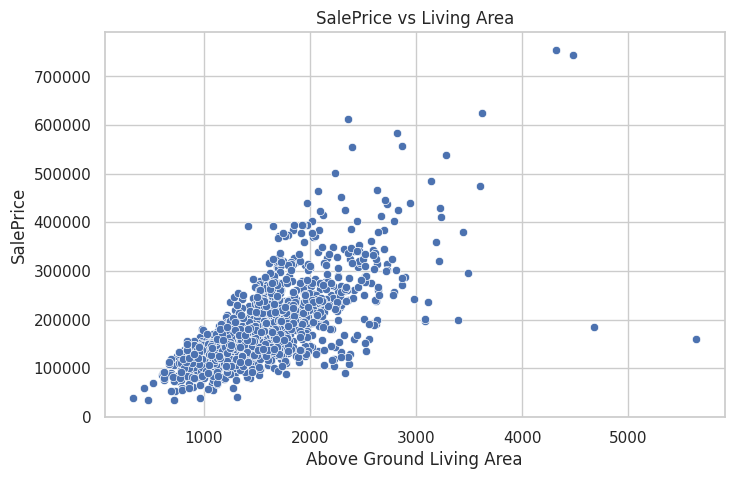

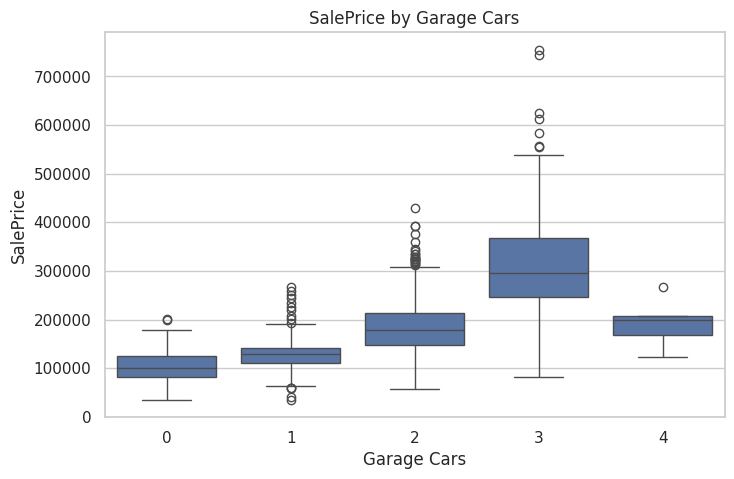

In [190]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="OverallQual",
    y="SalePrice"
)

plt.title("SalePrice by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")
plt.show()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("SalePrice vs Living Area")
plt.xlabel("Above Ground Living Area")
plt.ylabel("SalePrice")
plt.show()

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="GarageCars",
    y="SalePrice"
)

plt.title("SalePrice by Garage Cars")
plt.xlabel("Garage Cars")
plt.ylabel("SalePrice")
plt.show()

In [191]:
def create_features(df):
    df = df.copy()

    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
    )

    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["HasGarage"] = df["GarageArea"].apply(lambda x: 1 if x > 0 else 0)
    df["HasBasement"] = df["TotalBsmtSF"].apply(lambda x:1 if x > 0 else 0)

    return df

train_fe = create_features(train)
test_fe = create_features(test)

train_fe[["TotalSF", "TotalBathrooms", "HouseAge", "RemodAge", "HasGarage", "HasBasement"]].head()

,TotalSF,TotalBathrooms,HouseAge,RemodAge,HasGarage,HasBasement
0,2566,3.5,5,5,1,1
1,2524,2.5,31,31,1,1
2,2706,3.5,7,6,1,1
3,2473,2.0,91,36,1,1
4,3343,3.5,8,8,1,1


In [192]:
target = "SalePrice_Log"

X = train_fe.drop(columns=["SalePrice", "SalePrice_Log"])
y = train_fe[target]

X_test = test_fe.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (1460, 86)
y shape: (1460,)
X_test shape: (1459, 86)


In [193]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric feature:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

numeric_features[:10]

categorical_features[:10]

Number of numeric feature: 43
Number of categorical features: 43


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1']

In [194]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (1168, 86)
X_valid shape: (292, 86)
y_train shape: (1168,)
y_valid shape: (292,)


In [195]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [196]:
def evaluate_regression_model(model, model_name):
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions_log = pipeline.predict(X_valid)

    rmse_log = np.sqrt(mean_squared_error(y_valid, predictions_log))
    mae_log = mean_absolute_error(y_valid, predictions_log)
    r2 = r2_score(y_valid, predictions_log)

    return {
    "Model": model_name,
    "RMSE_Log": rmse_log,
    "MAE_Log": mae_log,
    "R2_Score": r2,
    "Pipeline": pipeline
}

In [197]:
models = [
    (LinearRegression(), "Linear Regression"),
    (Ridge(alpha=10), "Ridge Regression"),
    (RandomForestRegressor(n_estimators=200, random_state=42), "Random Forest"),
    (GradientBoostingRegressor(random_state=42), "Gradient Boosting")
]

results = []

for model, model_name in models:
    result = evaluate_regression_model(model, model_name)
    results.append(result)

model_results = pd.DataFrame([
    {
        "Model": result["Model"],
        "RMSE_Log": result["RMSE_Log"],
        "MAE_Log": result["MAE_Log"],
        "R2_Score": result["R2_Score"]
    }
    for result in results
]).sort_values("RMSE_Log")

model_results


,Model,RMSE_Log,MAE_Log,R2_Score
0,Linear Regression,0.128728,0.089036,0.911200
3,Gradient Boosting,0.136493,0.087825,0.900165
1,Ridge Regression,0.137084,0.095513,0.899299
2,Random Forest,0.146365,0.097609,0.885201


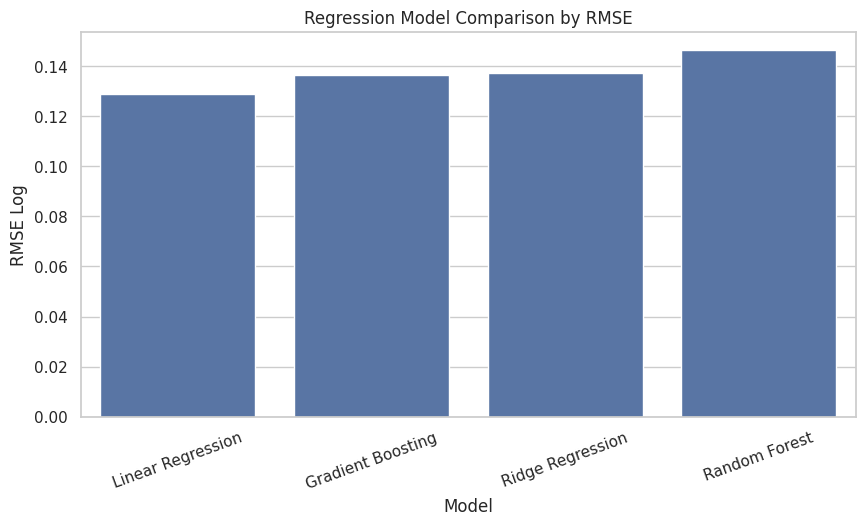

In [198]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="RMSE_Log"
)

plt.title("Regression Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE Log")
plt.xticks(rotation=20)
plt.show()

## Insight

The model with the lowest RMSE is the best model in this comparison because it makes the smallest prediction error on the validation data.

In [199]:
best_model = GradientBoostingRegressor(random_state=42)

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

cv_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=5, 
    scoring="neg_root_mean_squared_error"
)

cv_rmse_scores = -cv_scores

print("CV RMSE scores:", cv_rmse_scores)
print("Mean CV RMSE:", cv_rmse_scores.mean())
print("Std CV RMSE:", cv_rmse_scores.std())

CV RMSE scores: [0.11496783 0.13512845 0.13206325 0.11253621 0.12631776]
Mean CV RMSE: 0.1242027004417682
Std CV RMSE: 0.009022454271219166


In [200]:
best_pipeline.fit(X, y)
print("Final regression model trained on full training data")

Final regression model trained on full training data


In [201]:
test_predictions_log = best_pipeline.predict(X_test)

test_predictions = np.expm1(test_predictions_log)

test_predictions[:10]

array([120705.24002831, 157705.66098798, 177711.46924661, 186113.15616731,
       193667.87162167, 171797.98131015, 178589.8625706 , 164844.74905298,
       188232.4377202 , 122959.56129127])

In [204]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})

submission.head()

submission.to_csv("/kaggle/working/house_price_submission.csv", index=False)

print("House price submission file created successfully.")

from IPython.display import FileLink

FileLink("/kaggle/working/house_price_submission.csv")

House price submission file created successfully.


/kaggle/working/house_price_submission.csv

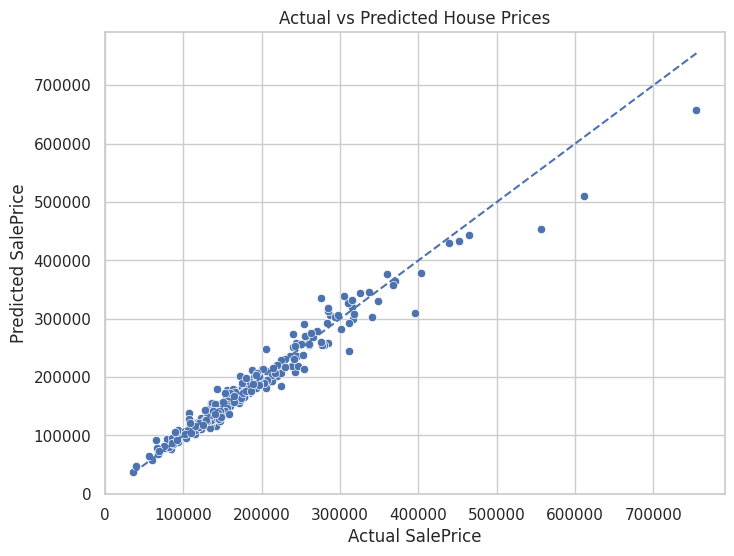

In [206]:
valid_predictions_log = best_pipeline.predict(X_valid)

valid_actual_price = np.expm1(y_valid)
valid_predicted_price = np.expm1(valid_predictions_log)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=valid_actual_price,
    y=valid_predicted_price
)

plt.plot(
    [valid_actual_price.min(), valid_actual_price.max()],
    [valid_actual_price.min(), valid_actual_price.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.show()

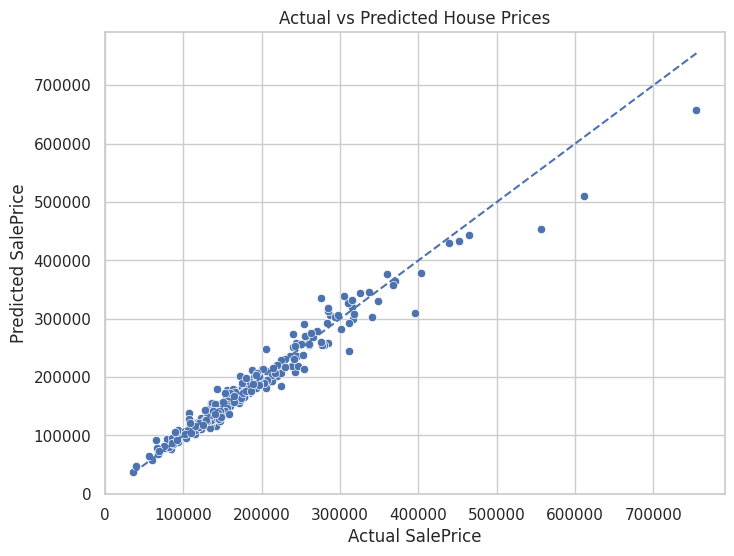

/kaggle/working/house_price_actual_vs_predicted.png

In [208]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=valid_actual_price,
    y=valid_predicted_price
)

plt.plot(
    [valid_actual_price.min(), valid_actual_price.max()],
    [valid_actual_price.min(), valid_actual_price.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

plt.savefig("/kaggle/working/house_price_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

FileLink("/kaggle/working/house_price_actual_vs_predicted.png")

## Key Findings

From this house price regression project, I found that:

1. House price prediction is a regression problem because the target is a continuous number.
2. SalePrice is right-skewed, so log transformation helps make the target more stable.
3. OverallQual, GrLivArea, GarageCars, GarageArea, and TotalBsmtSF are strongly related to house prices.
4. Feature engineering such as TotalSF, TotalBathrooms, HouseAge, and HasGarage can help improve model performance.
5. RMSE is useful for evaluating regression models.
6. Gradient Boosting and Random Forest can capture more complex patterns than simple Linear Regression.
7. The final model can generate predictions for Kaggle test data.

## What I Learned

In this project, I practiced:

- Building a regression model
- Understanding the difference between classification and regression
- Applying log transformation to the target variable
- Handling numeric and categorical features
- Using Pipeline and ColumnTransformer
- Comparing regression models
- Evaluating models with RMSE, MAE, and R2 Score
- Creating a Kaggle submission file for house price prediction

## Next Step

The next step is to improve the regression model using:

- Hyperparameter tuning
- Cross-validation
- XGBoost
- LightGBM
- Feature selection
- Outlier handling